# Notebook 01: Database Validation & Sample Overview

**Purpose:** Verify the ingestion pipeline has correctly populated the database before any analysis begins.

- Confirm all 171 SPARC galaxies and their radial profiles are present
- Generate a sample-level summary statistics table
- Plot representative rotation curves showing raw baryonic components

**Prerequisites:** Run `notebooks/00_setup.ipynb` first.

In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sqlalchemy import func, text

from src.database import Galaxy, RadialProfile, get_session, init_db, query_profiles_as_dataframe
from src.utils import get_project_root, setup_logger

%matplotlib inline
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

logger = setup_logger('notebook_01')
project_root = get_project_root()
engine = init_db()
session = get_session(engine)

FIGURES_DIR = project_root / 'results' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

UPSILON_DISK = 0.5
UPSILON_BULGE = 0.7

print('Setup complete.')

2026-03-13 15:44:44 | INFO     | src.database | Database initialized at C:\Projects\ISM\tapered-model-comparison\data\processed\galaxy_dynamics.db


Setup complete.


## 1. Galaxy Count Verification

In [2]:
n_galaxies = session.query(func.count(Galaxy.galaxy_id)).scalar()
n_profiles = session.query(func.count(RadialProfile.profile_id)).scalar()

print(f'Galaxies in DB:              {n_galaxies}')
print(f'Total radial profile rows:   {n_profiles}')

if n_galaxies < 171:
    print(f'WARNING: Expected 171 galaxies, found {n_galaxies}. Check ingestion.')
else:
    print(f'OK: {n_galaxies} galaxies loaded.')

Galaxies in DB:              175
Total radial profile rows:   3391
OK: 175 galaxies loaded.


## 2. Sample Properties Summary

In [3]:
gal_df = pd.read_sql('SELECT * FROM galaxies', engine)

summary_cols = ['distance_mpc', 'inclination', 'luminosity_band_36', 'r_disk_kpc', 'v_flat']
col_labels = {
    'distance_mpc': 'Distance (Mpc)',
    'inclination': 'Inclination (deg)',
    'luminosity_band_36': 'Luminosity (10⁹ L☉)',
    'r_disk_kpc': 'R_disk (kpc)',
    'v_flat': 'V_flat (km/s)',
}

rows = []
for col in summary_cols:
    if col not in gal_df.columns:
        continue
    s = gal_df[col].dropna()
    rows.append({
        'Property': col_labels.get(col, col),
        'N': len(s),
        'N_missing': n_galaxies - len(s),
        'Min': f'{s.min():.3g}',
        'Median': f'{s.median():.3g}',
        'Max': f'{s.max():.3g}',
    })

summary_df = pd.DataFrame(rows)
print('Sample properties summary:')
display(summary_df)

Sample properties summary:


,Property,N,N_missing,Min,Median,Max
0,Distance (Mpc),175,0,0.98,16.5,128
1,Inclination (deg),175,0,15,60,90
2,Luminosity (10⁹ L☉),175,0,0.012,3.89,490
3,R_disk (kpc),175,0,0.18,2.33,18.8
4,V_flat (km/s),175,0,0,88.1,332


In [4]:
# Quality flag distribution
quality_df = pd.read_sql(
    'SELECT quality_flag, COUNT(*) as n FROM galaxies GROUP BY quality_flag ORDER BY quality_flag',
    engine
)
quality_df['pct'] = (quality_df['n'] / n_galaxies * 100).round(1)
print('Quality flag distribution:')
display(quality_df)

Quality flag distribution:


,quality_flag,n,pct
0,1,99,56.6
1,2,64,36.6
2,3,12,6.9


## 3. Profile Data Integrity

In [5]:
# Per-galaxy point counts
pts_df = pd.read_sql(
    'SELECT galaxy_id, COUNT(*) as n_points FROM radial_profiles GROUP BY galaxy_id',
    engine
)
print(f'Points per galaxy — min: {pts_df["n_points"].min()}, '
      f'median: {pts_df["n_points"].median():.0f}, '
      f'max: {pts_df["n_points"].max()}')

low_count = pts_df[pts_df['n_points'] < 5]
print(f'\nGalaxies with fewer than 5 data points: {len(low_count)}')
if len(low_count) > 0:
    print(low_count.to_string(index=False))

Points per galaxy — min: 4, median: 14, max: 115

Galaxies with fewer than 5 data points: 4
galaxy_id  n_points
   D512-2         4
  NGC6789         4
 UGC00634         4
 UGC07232         4


In [6]:
# v_baryon_total completeness
null_vbary = pd.read_sql(
    'SELECT COUNT(*) as n FROM radial_profiles WHERE v_baryon_total IS NULL',
    engine
).iloc[0]['n']
print(f'Rows with NULL v_baryon_total: {null_vbary}')
if null_vbary == 0:
    print('OK: All baryonic velocities are populated.')
else:
    print('WARNING: Some v_baryon_total entries are missing. These galaxies may be skipped in fitting.')

Rows with NULL v_baryon_total: 0
OK: All baryonic velocities are populated.


## 4. Representative Rotation Curves

Six galaxies spanning the SPARC mass range: dwarf irregulars, LSBs, and massive spirals.  
This verifies that the signed-square baryonic convention ($V_{bary} = \sqrt{|V_i|V_i}$ summed) is handled correctly.

In [7]:
SAMPLE_GALAXIES = ['NGC3198', 'UGC02885', 'DDO154', 'NGC6503', 'NGC2403', 'ESO563-G021']

# Verify all sample galaxies are in the DB; substitute if any are missing
all_ids = set(gal_df['galaxy_id'].values)
available = [g for g in SAMPLE_GALAXIES if g in all_ids]
if len(available) < len(SAMPLE_GALAXIES):
    missing = [g for g in SAMPLE_GALAXIES if g not in all_ids]
    print(f'WARNING: {missing} not in DB, substituting from available galaxies.')
    extras = [g for g in all_ids if g not in SAMPLE_GALAXIES][:len(missing)]
    available.extend(extras)
SAMPLE_GALAXIES = available[:6]
print(f'Plotting: {SAMPLE_GALAXIES}')

Plotting: ['NGC3198', 'UGC02885', 'DDO154', 'NGC6503', 'NGC2403', 'ESO563-G021']


Saved: C:\Projects\ISM\tapered-model-comparison\results\figures\01_representative_rotation_curves.png


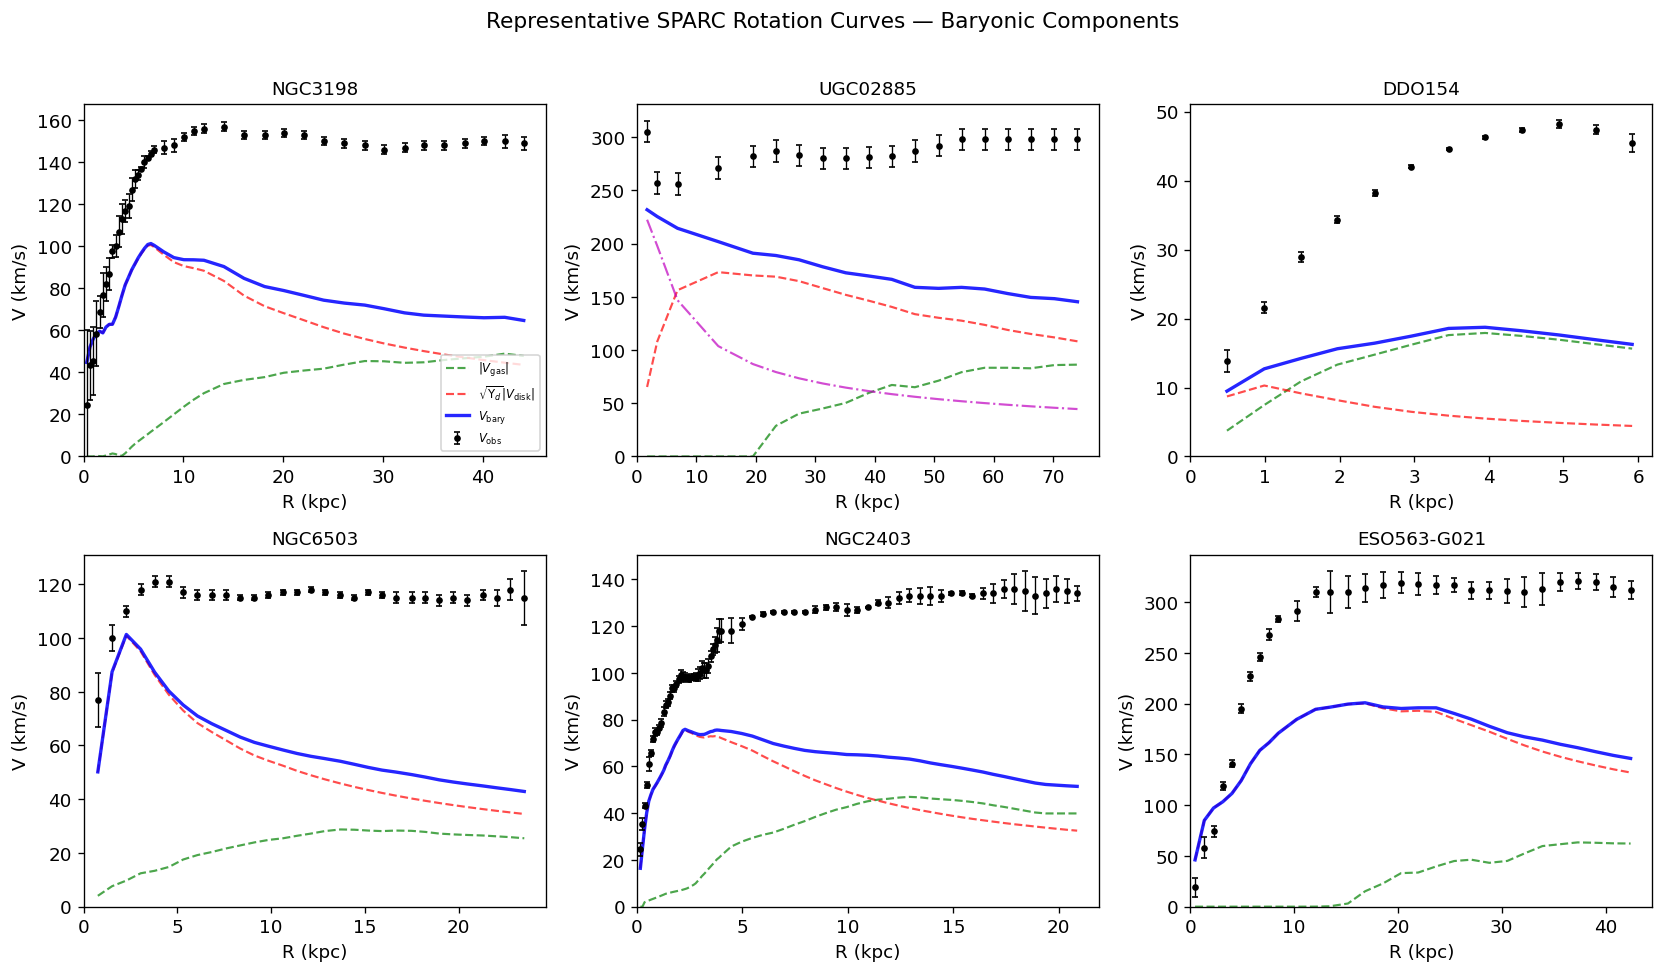

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes_flat = axes.flatten()

for ax, gid in zip(axes_flat, SAMPLE_GALAXIES):
    df = query_profiles_as_dataframe(session, gid)
    if df.empty:
        ax.text(0.5, 0.5, f'{gid}\n(no data)', ha='center', va='center', transform=ax.transAxes)
        ax.set_visible(True)
        continue

    r = df['radius_kpc'].values
    v_obs = df['v_obs'].values
    v_err = df['v_err'].fillna(0).values
    v_gas = df['v_gas'].values
    v_disk = df['v_disk'].values
    v_bulge = df['v_bulge'].values
    v_bary = df['v_baryon_total'].values

    ax.errorbar(r, v_obs, yerr=np.where(v_err > 0, v_err, np.nan),
                fmt='ko', ms=3, capsize=2, lw=0.8, label=r'$V_{\rm obs}$', zorder=5)
    ax.plot(r, np.abs(v_gas), 'g--', lw=1.3, alpha=0.7, label=r'$|V_{\rm gas}|$')
    ax.plot(r, np.sqrt(UPSILON_DISK) * np.abs(v_disk), 'r--', lw=1.3, alpha=0.7,
            label=r'$\sqrt{\Upsilon_d}|V_{\rm disk}|$')
    if np.any(v_bulge != 0):
        ax.plot(r, np.sqrt(UPSILON_BULGE) * np.abs(v_bulge), 'm-.', lw=1.3, alpha=0.7,
                label=r'$\sqrt{\Upsilon_b}|V_{\rm bulge}|$')
    ax.plot(r, v_bary, 'b-', lw=2, alpha=0.85, label=r'$V_{\rm bary}$')

    ax.set_title(gid, fontsize=11)
    ax.set_xlabel('R (kpc)')
    ax.set_ylabel('V (km/s)')
    ax.set_xlim(left=0)
    ax.set_ylim(bottom=0)

axes_flat[0].legend(fontsize=7, loc='lower right')
fig.suptitle('Representative SPARC Rotation Curves — Baryonic Components', fontsize=13, y=1.01)
plt.tight_layout()

out_path = FIGURES_DIR / '01_representative_rotation_curves.png'
fig.savefig(out_path, dpi=150, bbox_inches='tight')
print(f'Saved: {out_path}')
plt.show()

In [9]:

# === Summary: key values for reference ===
n_q1 = int(quality_df[quality_df['quality_flag'] == 1]['n'].sum())
n_q2 = int(quality_df[quality_df['quality_flag'] == 2]['n'].sum())
n_q3 = int(quality_df[quality_df['quality_flag'] == 3]['n'].sum())

min_pts  = int(pts_df['n_points'].min())
med_pts  = int(pts_df['n_points'].median())
max_pts  = int(pts_df['n_points'].max())
n_lt5    = len(pts_df[pts_df['n_points'] < 5])

print('=== Notebook 01 Summary ===')
print(f'Galaxies ingested:                 {n_galaxies}')
print(f'Total radial profile rows:         {n_profiles}')
print(f'Quality Q=1 / Q=2 / Q=3:          {n_q1} / {n_q2} / {n_q3}')
print(f'Points per galaxy — min / median / max: {min_pts} / {med_pts} / {max_pts}')
print(f'Galaxies with < 5 points:          {n_lt5}')
print(f'NULL v_baryon_total rows:          {null_vbary}')
print()
print('The rotation curves confirm the signed-square convention handles')
print('negative gas contributions without imaginary results.')


=== Notebook 01 Summary ===
Galaxies ingested:                 175
Total radial profile rows:         3391
Quality Q=1 / Q=2 / Q=3:          99 / 64 / 12
Points per galaxy — min / median / max: 4 / 14 / 115
Galaxies with < 5 points:          4
NULL v_baryon_total rows:          0

The rotation curves confirm the signed-square convention handles
negative gas contributions without imaginary results.
